# 빈도수 기반 텍스트 분석 : 다음 영화 리뷰

1. 데이터 준비 : 로딩, 필요한 데이터 추출
2. 데이터 전처리 : 분석 대상 단어 집합
3. 데이터 분석 : 빈도수
4. 시각화 : 수평 막대 그래프, 워드클라우드

In [1]:
### 1. 데이터 준비
import pandas as pd
import numpy as np

datafile = './data/daum_movie_review.csv'
data_df = pd.read_csv(datafile, usecols=['review'])
print(type(data_df))
data_df.head()

<class 'pandas.core.frame.DataFrame'>


,review
0,돈 들인건 티가 나지만 보는 내내 하품만
1,몰입할수밖에 없다. 어렵게 생각할 필요없다. 내가 전투에 참여한듯 손에 땀이남.
2,이전 작품에 비해 더 화려하고 스케일도 커졌지만.... 전국 맛집의 음식들을 한데 ...
3,이 정도면 볼만하다고 할 수 있음!
4,재미있다


In [2]:
# 기호를 없애면 리뷰에 null이 생길 수 있어 미리 기호를 빼고 결측치를 찾기
# 는 다음번에 해보기
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14725 entries, 0 to 14724
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  14725 non-null  object
dtypes: object(1)
memory usage: 115.2+ KB


In [3]:
reviews = list(data_df.review)
type(reviews), len(reviews), reviews[:5]

(list,
 14725,
 ['돈 들인건 티가 나지만 보는 내내 하품만',
  '몰입할수밖에 없다. 어렵게 생각할 필요없다. 내가 전투에 참여한듯 손에 땀이남.',
  '이전 작품에 비해 더 화려하고 스케일도 커졌지만.... 전국 맛집의 음식들을 한데 모은 것까지는 좋았으나 이걸 모두 한 그릇에 섞어버린 듯한 느낌... 그래도 다음 작품을 기대하게 만든다...',
  '이 정도면 볼만하다고 할 수 있음!',
  '재미있다'])

### 2. 데이터 전처리 -> 단어 집합

In [4]:
from konlpy.tag import Okt
t = Okt()

nouns = []
# 명사만 추출
for i in range(len(reviews)):
    nouns += t.nouns(reviews[i])

# 토큰 수
print(f"토큰 수 : {len(nouns):,}개")

# 토큰 일부 확인
nouns[:10]

토큰 수 : 126,063개


['돈', '티', '나', '내내', '하품', '몰입', '생각', '내', '전투', '참여']

In [5]:
# 명사(일반 명사, 고유 명사), 동사, 형용사 단어 추출
my_tags = ["Noun", "Verb", "Adjective"]

# 불용어 삭제 : 의미없는데 고빈도로 나오는 단어 추가
my_stopwords = ["내", "내내", "티", "나", "들인건", "할수밖에", "없다", "보는", "정말", "하는", "보고", "입니다", "그냥", "정도", "해서", "있는", "봤는데"]
tokens = []
for i in range(len(reviews)):
    tokens += [word for word, tag in t.pos(reviews[i]) if tag in my_tags and word not in my_stopwords and len(word) > 1]

# 토큰 수
print(f"토큰 수 : {len(tokens):,}개")
# 토큰 일부 확인
tokens[:10]

토큰 수 : 156,078개


['하품', '몰입', '어렵게', '생각', '필요없다', '전투', '참여', '이남', '이전', '작품']

### 3. 빈도수 계산

In [6]:
from collections import Counter

# Counter 객체 생성
const_counter = Counter(tokens)

# 단어 수
print(f"단어 수 : {len(const_counter):,}개")

# Counter 객체 내 (단어, 빈도수) 확인
print(list(const_counter.items())[:10])

단어 수 : 25,541개
[('하품', 33), ('몰입', 210), ('어렵게', 5), ('생각', 1027), ('필요없다', 15), ('전투', 11), ('참여', 8), ('이남', 3), ('이전', 16), ('작품', 241)]


In [7]:
# 빈도수 상위 단어의 (단어, 빈도수) 튜플 리스트 추출
const_counter.most_common(50)

[('영화', 6691),
 ('연기', 1293),
 ('감동', 1223),
 ('생각', 1027),
 ('배우', 847),
 ('사람', 819),
 ('스토리', 815),
 ('진짜', 781),
 ('눈물', 737),
 ('최고', 682),
 ('재미', 641),
 ('마지막', 612),
 ('시간', 596),
 ('마동석', 556),
 ('광주', 530),
 ('윤계상', 517),
 ('기대', 516),
 ('내용', 494),
 ('장면', 438),
 ('원작', 422),
 ('평점', 407),
 ('느낌', 400),
 ('신파', 387),
 ('좋은', 377),
 ('중간', 348),
 ('합니다', 344),
 ('재밌게', 335),
 ('가족', 335),
 ('마블', 334),
 ('봤습니다', 334),
 ('감독', 333),
 ('이런', 332),
 ('다시', 322),
 ('한국', 321),
 ('같은', 320),
 ('없는', 316),
 ('처음', 310),
 ('부분', 302),
 ('역사', 299),
 ('음악', 290),
 ('우리', 277),
 ('가슴', 277),
 ('봤어요', 275),
 ('한번', 273),
 ('액션', 268),
 ('송강호', 261),
 ('공포영화', 259),
 ('인생', 258),
 ('하나', 258),
 ('별로', 258)]

#### 4. 단어 빈도 그래프 시각화

In [8]:
# 데이터 준비 : 빈도수 상위 20개의 단어만 추출
# x 데이터 : word, y 데이터 : count
x = [word for word, _ in const_counter.most_common(20)]
y = [count for _, count in const_counter.most_common(20)]
print(x[:10])
print(y[:10])

['영화', '연기', '감동', '생각', '배우', '사람', '스토리', '진짜', '눈물', '최고']
[6691, 1293, 1223, 1027, 847, 819, 815, 781, 737, 682]


In [9]:
# matplotlib 한글 폰트 설정
from matplotlib import font_manager, rc
font_path = "c:/Windows/Fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

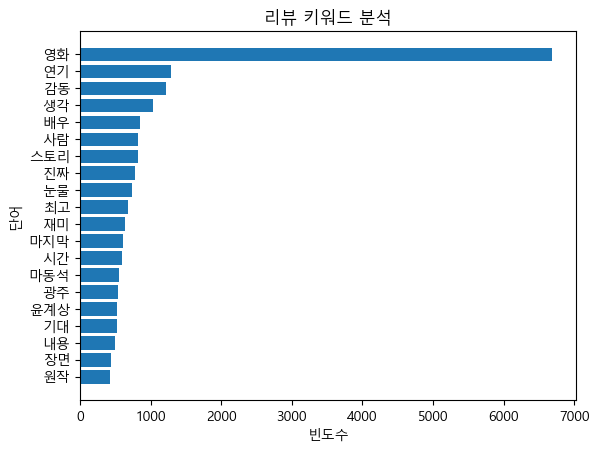

In [10]:
import matplotlib.pyplot as plt

# 수평 막대그래프
plt.barh(x[::-1], y[::-1])

# 그래프 정보 추가 
plt.title('리뷰 키워드 분석')
plt.xlabel('빈도수')
plt.ylabel('단어')

# 화면에 출력
plt.show()

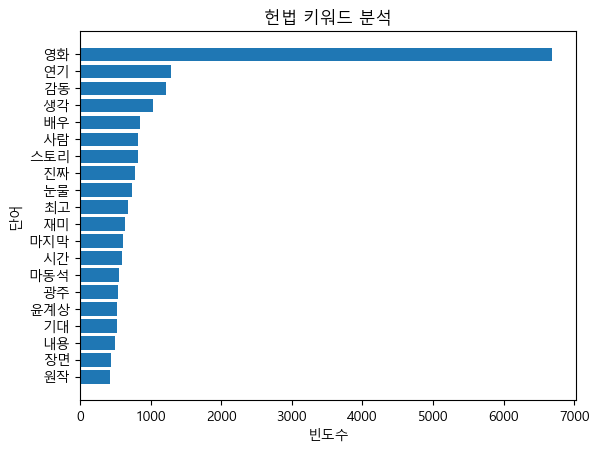

In [ ]:
# 그래프 저장 : 그래프 생성 후 바로 savefig 사용
outputfile = './result/movie_review_bargraph.png'

# 수평 막대그래프
plt.barh(x[::-1], y[::-1])

# 그래프 정보 추가 
plt.title('리뷰 키워드 분석')
plt.xlabel('빈도수')
plt.ylabel('단어')

# 파일로 저장
plt.savefig(outputfile)

### 5. 워드 클라우드 시각화

In [12]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 한글 폰트 path 지정
font_path = "c:/Windows/fonts/malgun.ttf"

# WordCloud 객체 생성
const_wc = WordCloud(font_path = font_path,
                     width= 800,
                     height= 600,
                     background_color= "ivory",
                     max_words= 50
                     )

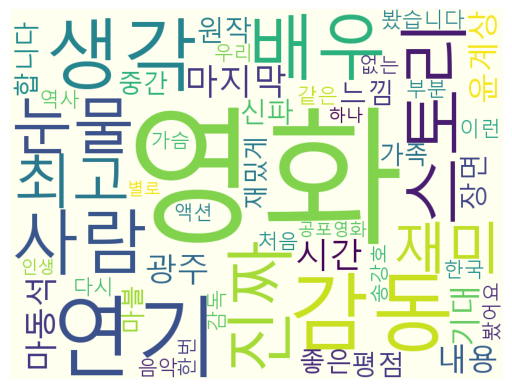

In [13]:
# 빈도 수로 워드클라우드 시각화
const_wc = const_wc.generate_from_frequencies(const_counter)

plt.imshow(const_wc)
plt.axis(False)
plt.show()